In [2]:
# Cell 1
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the images in grayscale
# Ensure you have a 'materials' folder with 'l1.png' and 'r1.png' in the same directory
imgL = cv2.imread('materials/l1.png', cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread('materials/r1.png', cv2.IMREAD_GRAYSCALE)

if imgL is None or imgR is None:
    print("Error: Could not load images. Check your file paths!")
else:
    print(f"Images loaded successfully! Image shape: {imgL.shape}")

Images loaded successfully! Image shape: (289, 382)


In [ ]:
# Cell 2
def block_matching(L, R, window_size, method='SAD', max_disparity=64):
    height, width = L.shape
    disparity_map = np.zeros((height, width), dtype=np.uint8)
    half_w = window_size // 2  # deh el Center pixel

    # Cast to int32 to prevent overflow during math operations since openCV's default uint8...
    # ...can not store -ve values 
    L = L.astype(np.int32)
    R = R.astype(np.int32)

    for y in range(half_w, height - half_w):
        for x in range(half_w, width - half_w):
            best_cost = float('inf')
            best_d = 0

            for d in range(max_disparity):
                if x - d - half_w < 0:
                    continue

                # Extract the windows
                window_L = L[y - half_w : y + half_w + 1, x - half_w : x + half_w + 1]
                window_R = R[y - half_w : y + half_w + 1, (x - d) - half_w : (x - d) + half_w + 1]

                # Calculate cost based on the chosen method
                if method == 'SAD':
                    cost = np.sum(np.abs(window_L - window_R))
                elif method == 'SSD':
                    cost = np.sum(np.square(window_L - window_R))

                if cost < best_cost:
                    best_cost = cost
                    best_d = d

            disparity_map[y, x] = best_d

    return disparity_map

In [4]:
# Cell 3
# Warning: This cell may take a minute to run depending on image size!
window_sizes = [1, 5, 9]

for w in window_sizes:
    print(f"Calculating SAD for window size {w}...")
    disp_sad = block_matching(imgL, imgR, w, method='SAD')
    cv2.imwrite(f'SAD_w{w}.png', cv2.normalize(disp_sad, None, 0, 255, cv2.NORM_MINMAX))
    
    print(f"Calculating SSD for window size {w}...")
    disp_ssd = block_matching(imgL, imgR, w, method='SSD')
    cv2.imwrite(f'SSD_w{w}.png', cv2.normalize(disp_ssd, None, 0, 255, cv2.NORM_MINMAX))

print("Block matching complete! All 6 maps saved.")

Calculating SAD for window size 1...
Calculating SSD for window size 1...
Calculating SAD for window size 5...
Calculating SSD for window size 5...
Calculating SAD for window size 9...
Calculating SSD for window size 9...
Block matching complete! All 6 maps saved.


In [5]:
# Cell 4
def dynamic_programming_stereo(L, R):
    height, width = L.shape
    disparity_map_L = np.zeros((height, width), dtype=np.uint8)
    
    # Constants from the assignment
    sigma = 2.0
    sigma_sq = sigma ** 2
    c0 = 1.0 
    
    L = L.astype(np.float32)
    R = R.astype(np.float32)
    
    print(f"Processing {height} rows with Dynamic Programming. This will take a moment...")
    
    for y in range(height):
        # Build the N-by-N matrix D for this scanline
        D = np.zeros((width, width))
        
        # 1. Initialize the boundaries (accumulation of skip penalties)
        # Because we use 0-indexing in Python, D(1,1) from the math is D[0,0] here
        d_00 = ((L[y, 0] - R[y, 0]) ** 2) / sigma_sq
        D[0, 0] = d_00
        
        for i in range(1, width):
            D[i, 0] = D[i-1, 0] + c0
            D[0, i] = D[0, i-1] + c0
            
        # 2. Fill the matrix using the recursive formula
        for i in range(1, width):
            for j in range(1, width):
                d_ij = ((L[y, i] - R[y, j]) ** 2) / sigma_sq
                
                match = D[i-1, j-1] + d_ij
                skip_left = D[i-1, j] + c0
                skip_right = D[i, j-1] + c0
                
                D[i, j] = min(match, skip_left, skip_right)
                
        # 3. Backtracking to find the optimal path
        i, j = width - 1, width - 1
        
        while i > 0 and j > 0:
            d_ij = ((L[y, i] - R[y, j]) ** 2) / sigma_sq
            
            # Reconstruct the costs to see which path was chosen
            cost_match = D[i-1, j-1] + d_ij
            cost_skip_left = D[i-1, j] + c0
            cost_skip_right = D[i, j-1] + c0
            
            min_cost = min(cost_match, cost_skip_left, cost_skip_right)
            
            if min_cost == cost_match:
                # Pixels match: absolute difference between i and j
                disparity_map_L[y, i] = abs(i - j)
                i -= 1
                j -= 1
            elif min_cost == cost_skip_left:
                # Pixel in L is skipped: disparity map of i is zero
                disparity_map_L[y, i] = 0
                i -= 1
            else:
                # Pixel in R is skipped: disparity map of j is zero
                # We only need to compute the left disparity map per the instructions
                j -= 1
                
        # Print progress every 50 rows
        if (y + 1) % 50 == 0:
            print(f"Completed {y + 1}/{height} rows...")

    return disparity_map_L, D # We return D from the last row for the bonus visualization!

In [6]:
# Cell 5
disp_dp, last_row_matrix = dynamic_programming_stereo(imgL, imgR)

# Save the Dynamic Programming disparity map
cv2.imwrite('DP_Disparity.png', cv2.normalize(disp_dp, None, 0, 255, cv2.NORM_MINMAX))
print("Dynamic programming complete! Map saved.")

Processing 289 rows with Dynamic Programming. This will take a moment...
Completed 50/289 rows...
Completed 100/289 rows...
Completed 150/289 rows...
Completed 200/289 rows...
Completed 250/289 rows...
Dynamic programming complete! Map saved.


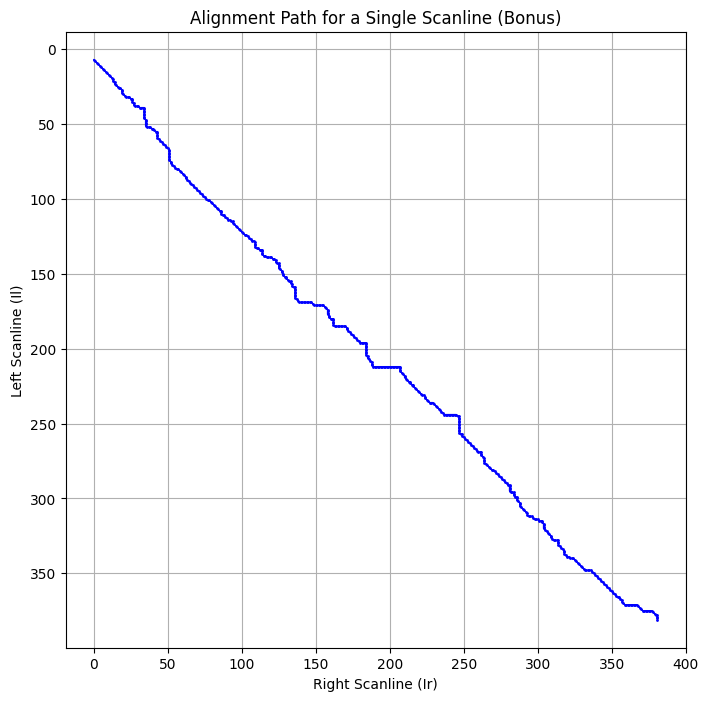

In [7]:
# Cell 6
def plot_alignment(D, L_row, R_row):
    N = D.shape[0]
    i, j = N - 1, N - 1
    
    path_i = [i]
    path_j = [j]
    
    c0 = 1.0
    sigma_sq = 4.0
    
    # Backtrack to map the path
    while i > 0 and j > 0:
        d_ij = ((float(L_row[i]) - float(R_row[j])) ** 2) / sigma_sq
        
        cost_match = D[i-1, j-1] + d_ij
        cost_skip_left = D[i-1, j] + c0
        cost_skip_right = D[i, j-1] + c0
        
        min_cost = min(cost_match, cost_skip_left, cost_skip_right)
        
        if min_cost == cost_match:
            i -= 1
            j -= 1
        elif min_cost == cost_skip_left:
            i -= 1
        else:
            j -= 1
            
        path_i.append(i)
        path_j.append(j)

    # Plot the graph
    plt.figure(figsize=(8, 8))
    plt.plot(path_j, path_i, marker='.', markersize=2, color='blue', linewidth=1)
    
    # Reverse the axis so (0,0) is at the top left, similar to an image matrix
    plt.gca().invert_yaxis()
    plt.title("Alignment Path for a Single Scanline (Bonus)")
    plt.xlabel("Right Scanline (Ir)")
    plt.ylabel("Left Scanline (Il)")
    plt.grid(True)
    plt.show()

# Run the bonus plot using the last row matrix generated from the previous cell
row_idx = imgL.shape[0] - 1
plot_alignment(last_row_matrix, imgL[row_idx, :], imgR[row_idx, :])